# 06 - Time-Based Train/Test Split

## Electricity Consumption Forecasting

### Objective

Prepare the feature-engineered dataset for machine learning by splitting it **chronologically** into training and testing data.

Because this is a time-series forecasting problem, we must **not randomly shuffle the observations**.

The model should learn from the past and be evaluated on a later period that it has never seen.


## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

## 2. Load the Modeling Dataset


In [2]:
file_path = "../data/processed/modeling_dataset.csv"

df = pd.read_csv(
    file_path,
    parse_dates=["DateTime"]
)

df = df.set_index("DateTime").sort_index()

print("Dataset shape:", df.shape)
print("Start:", df.index.min())
print("End:", df.index.max())

df.head()

Dataset shape: (24415, 12)
Start: 2006-12-23 17:00:00
End: 2009-10-05 23:00:00


,Electricity_Consumption,Hour,DayOfWeek,Month,Quarter,IsWeekend,Lag_1h,Lag_24h,Lag_168h,Rolling_24h,Rolling_168h,Target_Next_Hour
DateTime,,,,,,,,,,,,
2006-12-23 17:00:00,5.452533,17,5,12,4,1,4.349100,1.496800,4.222889,2.934890,1.763888,3.879400
2006-12-23 18:00:00,3.879400,18,5,12,4,1,5.452533,2.686967,3.632200,3.099713,1.771207,4.117833
2006-12-23 19:00:00,4.117833,19,5,12,4,1,3.879400,3.938167,3.400233,3.149397,1.772679,4.181400
2006-12-23 20:00:00,4.181400,20,5,12,4,1,4.117833,3.536067,3.268567,3.156883,1.776950,3.288433
2006-12-23 21:00:00,3.288433,21,5,12,4,1,4.181400,4.548667,3.056467,3.183772,1.782384,4.327933


## 3. Define Features and Target

The target is `Target_Next_Hour`.

The ten features created in Notebook 05 are used as the initial forecasting inputs.


In [3]:
feature_columns = [
    "Hour",
    "DayOfWeek",
    "Month",
    "Quarter",
    "IsWeekend",
    "Lag_1h",
    "Lag_24h",
    "Lag_168h",
    "Rolling_24h",
    "Rolling_168h"
]

target_column = "Target_Next_Hour"

X = df[feature_columns].copy()
y = df[target_column].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (24415, 10)
y shape: (24415,)


## 4. Check the Target and Features

Before splitting, verify that there are no missing values and that the index is chronological.


In [4]:
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())
print("Chronological order:", df.index.is_monotonic_increasing)


Missing values in X: 0
Missing values in y: 0
Chronological order: True


## 5. Determine the Time-Based Split

We use an **80% training / 20% testing** split.

The first 80% of the timeline is used for training.

The final 20% of the timeline is reserved as unseen test data.

This simulates the real forecasting situation:

**Past → Train**

**Future → Test**


In [5]:
split_index = int(len(df) * 0.80)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))
print("Training percentage:", len(train_df) / len(df) * 100)
print("Testing percentage:", len(test_df) / len(df) * 100)


Training rows: 19532
Testing rows: 4883
Training percentage: 80.0
Testing percentage: 20.0


## 6. Inspect the Training and Testing Periods

The most important check is that the test period occurs **after** the training period.


In [6]:
print("TRAINING PERIOD")
print("Start:", train_df.index.min())
print("End:", train_df.index.max())

print("\nTESTING PERIOD")
print("Start:", test_df.index.min())
print("End:", test_df.index.max())

print("\nTest starts after training:",
      test_df.index.min() > train_df.index.max())


TRAINING PERIOD
Start: 2006-12-23 17:00:00
End: 2009-03-16 12:00:00

TESTING PERIOD
Start: 2009-03-16 13:00:00
End: 2009-10-05 23:00:00

Test starts after training: True


## 7. Create X_train, X_test, y_train and y_test


In [7]:
X_train = train_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

y_train = train_df[target_column].copy()
y_test = test_df[target_column].copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (19532, 10)
X_test : (4883, 10)
y_train: (19532,)
y_test : (4883,)


## 8. Inspect the First and Last Training Observations


In [8]:
print("First training observations:")
display(train_df[[target_column] + feature_columns].head())

print("\nLast training observations:")
display(train_df[[target_column] + feature_columns].tail())


First training observations:


,Target_Next_Hour,Hour,DayOfWeek,Month,Quarter,IsWeekend,Lag_1h,Lag_24h,Lag_168h,Rolling_24h,Rolling_168h
DateTime,,,,,,,,,,,
2006-12-23 17:00:00,3.879400,17,5,12,4,1,4.349100,1.496800,4.222889,2.934890,1.763888
2006-12-23 18:00:00,4.117833,18,5,12,4,1,5.452533,2.686967,3.632200,3.099713,1.771207
2006-12-23 19:00:00,4.181400,19,5,12,4,1,3.879400,3.938167,3.400233,3.149397,1.772679
2006-12-23 20:00:00,3.288433,20,5,12,4,1,4.117833,3.536067,3.268567,3.156883,1.776950
2006-12-23 21:00:00,4.327933,21,5,12,4,1,4.181400,4.548667,3.056467,3.183772,1.782384



Last training observations:


,Target_Next_Hour,Hour,DayOfWeek,Month,Quarter,IsWeekend,Lag_1h,Lag_24h,Lag_168h,Rolling_24h,Rolling_168h
DateTime,,,,,,,,,,,
2009-03-16 08:00:00,1.351367,8,0,3,1,0,1.950333,1.661133,1.364100,1.311192,1.324361
2009-03-16 09:00:00,1.359700,9,0,3,1,0,1.362967,3.329100,1.342600,1.298768,1.324355
2009-03-16 10:00:00,1.373600,10,0,3,1,0,1.351367,1.526500,1.412467,1.216363,1.324407
2009-03-16 11:00:00,1.351733,11,0,3,1,0,1.359700,1.274700,1.607400,1.209413,1.324093
2009-03-16 12:00:00,1.019467,12,0,3,1,0,1.373600,1.618267,1.753200,1.213533,1.322701


## 9. Inspect the First and Last Testing Observations


In [9]:
print("First testing observations:")
display(test_df[[target_column] + feature_columns].head())

print("\nLast testing observations:")
display(test_df[[target_column] + feature_columns].tail())


First testing observations:


,Target_Next_Hour,Hour,DayOfWeek,Month,Quarter,IsWeekend,Lag_1h,Lag_24h,Lag_168h,Rolling_24h,Rolling_168h
DateTime,,,,,,,,,,,
2009-03-16 13:00:00,0.266300,13,0,3,1,0,1.351733,0.811233,1.751133,1.202428,1.320311
2009-03-16 14:00:00,0.277667,14,0,3,1,0,1.019467,2.634567,2.494667,1.211104,1.315956
2009-03-16 15:00:00,0.315533,15,0,3,1,0,0.266300,1.371167,0.573600,1.112426,1.302692
2009-03-16 16:00:00,0.297867,16,0,3,1,0,0.277667,0.482733,0.389967,1.066864,1.300931
2009-03-16 17:00:00,0.318733,17,0,3,1,0,0.315533,1.428967,0.625867,1.059897,1.300488



Last testing observations:


,Target_Next_Hour,Hour,DayOfWeek,Month,Quarter,IsWeekend,Lag_1h,Lag_24h,Lag_168h,Rolling_24h,Rolling_168h
DateTime,,,,,,,,,,,
2009-10-05 19:00:00,2.439833,19,0,10,4,0,0.921133,1.873667,2.153767,0.981228,0.993635
2009-10-05 20:00:00,1.991933,20,0,10,4,0,0.943600,3.428667,1.717100,0.942475,0.986431
2009-10-05 21:00:00,1.453433,21,0,10,4,0,2.439833,2.687900,2.058200,0.901274,0.990733
2009-10-05 22:00:00,0.935167,22,0,10,4,0,1.991933,1.593300,2.048900,0.872275,0.990339
2009-10-05 23:00:00,0.410483,23,0,10,4,0,1.453433,0.471200,0.447367,0.866447,0.986794


## 10. Establish a Simple Baseline

Before using machine-learning algorithms, we need a baseline.

A simple baseline predicts the next-hour consumption using the consumption from one hour earlier (`Lag_1h`).

This gives us a reference point. A machine-learning model should perform better than this baseline to justify its additional complexity.


In [10]:
baseline_predictions = X_test["Lag_1h"]

print("Baseline predictions:", baseline_predictions.shape)
print("Actual test values:", y_test.shape)


Baseline predictions: (4883,)
Actual test values: (4883,)


## 11. Calculate Baseline MAE

Mean Absolute Error (MAE) measures the average absolute difference between actual and predicted consumption.

Lower MAE is better.


In [11]:
from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

print("Baseline MAE:", baseline_mae)


Baseline MAE: 0.534100681393319


## 12. Calculate Baseline RMSE

RMSE penalizes large errors more strongly than MAE.

Lower RMSE is better.


In [12]:
from sklearn.metrics import mean_squared_error

baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_predictions)
)

print("Baseline RMSE:", baseline_rmse)


Baseline RMSE: 0.7952098232328327


## 13. Calculate Baseline R²

R² indicates how much of the variation in the target is explained by the predictions.

For a baseline, this is only a reference value. The main goal is to establish a benchmark that future models should improve upon.


In [13]:
from sklearn.metrics import r2_score

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("Baseline R²:", baseline_r2)


Baseline R²: -0.2812996599045363


## 14. Visualize the Train/Test Split

A time-series plot helps verify that the split is chronological and that the test period is a later segment of the dataset.


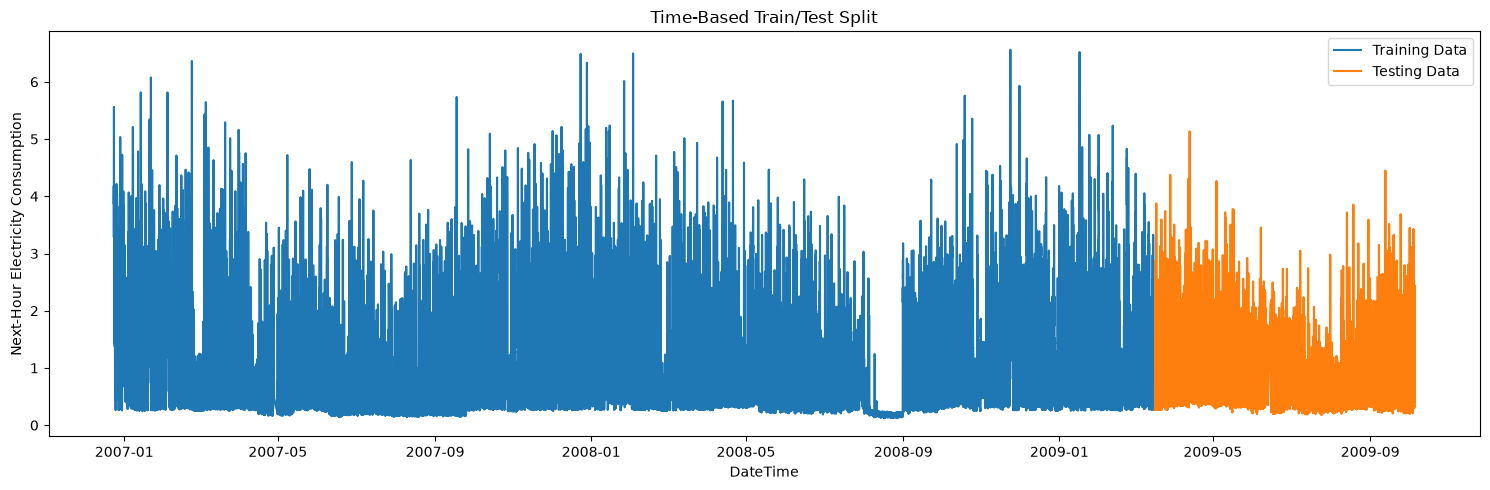

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(
    train_df.index,
    train_df[target_column],
    label="Training Data"
)

plt.plot(
    test_df.index,
    test_df[target_column],
    label="Testing Data"
)

plt.title("Time-Based Train/Test Split")
plt.xlabel("DateTime")
plt.ylabel("Next-Hour Electricity Consumption")
plt.legend()
plt.tight_layout()
plt.show()


## 15. Save the Training and Testing Datasets

Saving the splits makes the project reproducible and allows later model notebooks to use exactly the same data.


In [15]:
train_output = "../data/processed/train_dataset.csv"
test_output = "../data/processed/test_dataset.csv"

train_df.to_csv(train_output, index_label="DateTime")
test_df.to_csv(test_output, index_label="DateTime")

print("Training dataset saved:", train_output)
print("Testing dataset saved:", test_output)


Training dataset saved: ../data/processed/train_dataset.csv
Testing dataset saved: ../data/processed/test_dataset.csv


## 16. Final Validation


In [16]:
print("===== FINAL SPLIT VALIDATION =====")
print("Total rows:", len(df))
print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

print("\nTraining:")
print(train_df.index.min(), "to", train_df.index.max())

print("\nTesting:")
print(test_df.index.min(), "to", test_df.index.max())

print("\nNo overlap:",
      train_df.index.max() < test_df.index.min())

print("\nBaseline:")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²  :", baseline_r2)


===== FINAL SPLIT VALIDATION =====
Total rows: 24415
Training rows: 19532
Testing rows: 4883

Training:
2006-12-23 17:00:00 to 2009-03-16 12:00:00

Testing:
2009-03-16 13:00:00 to 2009-10-05 23:00:00

No overlap: True

Baseline:
MAE : 0.534100681393319
RMSE: 0.7952098232328327
R²  : -0.2812996599045363


## Conclusion

The data is now split correctly for time-series forecasting.

### Completed

- Loaded the feature-engineered dataset.
- Defined the 10 forecasting features.
- Defined the next-hour target.
- Used an 80/20 chronological split.
- Verified that the test period occurs after the training period.
- Created a simple previous-hour baseline.
- Calculated baseline MAE, RMSE and R².
- Saved separate training and testing datasets.

### Next notebook

**07 - Model Training**

We will train and compare machine-learning models such as:

1. Linear Regression
2. Random Forest Regressor
3. Gradient Boosting / HistGradientBoosting

The models will be evaluated against the baseline using the same test period.
